[*********************100%***********************]  1 of 1 completed

Date
2023-01-04    0.025665
2023-01-05    0.040110
2023-01-06    0.005837
2023-01-09   -0.009497
2023-01-10    0.001598
Name: HSBA.L, dtype: float64


<Axes: xlabel='Date'>

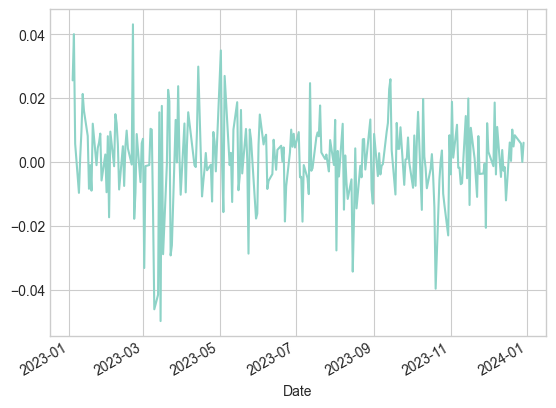

In [263]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Download historical data for HSBC Holdings plc (HSBA.L) from Yahoo Finance
data = yf.download("HSBA.L", start="2023-01-01", end="2024-01-01")
returns = data["Close"].squeeze().pct_change().dropna()
# Display the first few rows of the returns and plot them
print(returns.head())
returns.plot()

In [264]:
def plot_daily_returns(returns):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    positive = returns.copy()
    negative = returns.copy()
    positive[positive < 0] = 0
    negative[negative > 0] = 0

    ax.bar(returns.index, positive, color="#1565C0", alpha=0.7, width=1, label="Positive return")
    ax.bar(returns.index, negative, color="#B71C1C", alpha=0.7, width=1, label="Negative return")

    ax.axhline(0, color="#555555", linewidth=0.8, zorder=3)
    ax.axhline(h_var, color="#B71C1C", linestyle="--", linewidth=1, 
               label=f"Historical VaR 99%: {h_var:.2%}", zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.set_title("HSBC Daily Returns", fontsize=13, fontweight="bold", pad=15, loc="left")
    ax.set_xlabel("Date", fontsize=10, color="#555555")
    ax.set_ylabel("Daily Return (%)", fontsize=10, color="#555555")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.tick_params(colors="#555555", labelsize=9)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
             ncol=3, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(bottom=0.2)
    plt.show()

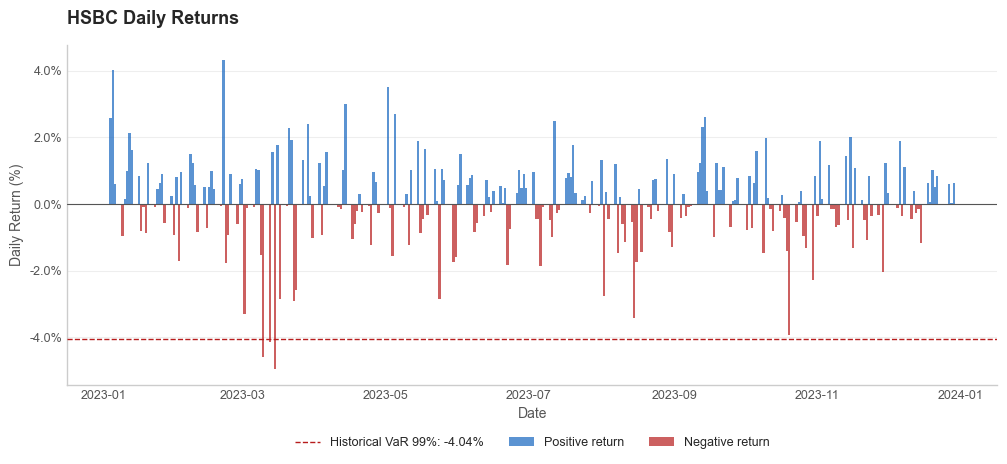

In [265]:
plot_daily_returns(returns)

In [266]:
# Value at Risk (VaR) calculations
import numpy as np
from scipy.stats import norm

# Historical VaR
def historical_var(returns, confidence = 0.99):
    return np.percentile(returns.dropna(), (1 - confidence) * 100)

# Parametric VaR
def parametric_var(returns, confidence = 0.99):
    mu = returns.mean()
    sigma = returns.std()
    return mu - sigma * norm.ppf(confidence)

In [267]:
portfolio_value = 10000 

h_var = historical_var(returns)
p_var = parametric_var(returns)

print(f"Portfolio value: £{portfolio_value:,.2f}")
print(f"Historical 99%: {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%: {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")

Portfolio value: £10,000.00
Historical 99%: -0.0404 → £404.19
Parametric 99%: -0.0297 → £296.68


In [268]:
def position_sizer(var_decimal, var_limit_gbp, current_price, proposed_shares=None):
    max_position_gbp = var_limit_gbp / abs(var_decimal)
    max_shares = int(max_position_gbp / current_price)
    
    print(f"VaR limit:          £{var_limit_gbp:,.2f}")
    print(f"Max position size:  £{max_position_gbp:,.2f}")
    print(f"Max shares:         {max_shares}")
    
    if proposed_shares is not None:
        proposed_value = proposed_shares * current_price
        proposed_var = proposed_value * abs(var_decimal)
        print(f"\nProposed shares:    {proposed_shares}")
        print(f"Proposed value:     £{proposed_value:,.2f}")
        print(f"Proposed VaR:       £{proposed_var:,.2f}")
        
        if proposed_shares > max_shares:
            print(f"\n⚠️  WARNING: Exceeds limit — reduce to {max_shares} shares")
        else:
            print(f"\n✅ Position is within your VaR limit")



In [269]:
current_price = data["Close"].squeeze().iloc[-1]

position_sizer(
    var_decimal=h_var,
    var_limit_gbp=300,
    current_price=current_price,
    proposed_shares=500
)

VaR limit:          £300.00
Max position size:  £7,422.19
Max shares:         11

Proposed shares:    500
Proposed value:     £317,162.78
Proposed VaR:       £12,819.51

⚠️  WARNING: Exceeds limit — reduce to 11 shares


In [270]:
from scipy.stats import t

def t_var(returns, confidence=0.99):
    nu, mu, sigma = t.fit(returns)
    return float(t.ppf(1 - confidence, nu, mu, sigma))

In [271]:
t_v = t_var(returns)

print(f"Portfolio value:    £{portfolio_value:,.2f}")
print(f"Historical 99%:     {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%:     {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")
print(f"T-distribution 99%: {t_v:.4f} → £{abs(t_v) * portfolio_value:,.2f}")
print(f"\nDegrees of freedom (ν): {t.fit(returns)[0]:.2f}")

Portfolio value:    £10,000.00
Historical 99%:     -0.0404 → £404.19
Parametric 99%:     -0.0297 → £296.68
T-distribution 99%: -0.0348 → £347.99

Degrees of freedom (ν): 3.85


In [272]:
def drawdown_analysis(returns, portfolio_value):
    cumulative = portfolio_value * (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    print(f"Starting portfolio value:  £{portfolio_value:,.2f}")
    print(f"Final portfolio value:     £{cumulative.iloc[-1]:,.2f}")
    print(f"Maximum drawdown:          {max_dd:.2%}")
    print(f"Worst single day loss:     {returns.min():.2%}")
    
    return cumulative, drawdown

In [273]:
cumulative, drawdown = drawdown_analysis(returns, portfolio_value)

Starting portfolio value:  £10,000.00
Final portfolio value:     £12,000.96
Maximum drawdown:          -17.51%
Worst single day loss:     -4.96%


In [274]:
from scipy.stats import t as t_dist
import numpy as np

def monte_carlo_drawdown(returns, portfolio_value=10000, n_simulations=1000, n_days=252):
    nu, mu, sigma = t_dist.fit(returns)
    
    simulated_returns = t_dist.rvs(nu, mu, sigma, size=(n_days, n_simulations))
    
    cumulative_paths = portfolio_value * np.cumprod(1 + simulated_returns, axis=0)
    
    max_drawdowns = []
    for i in range(n_simulations):
        path = cumulative_paths[:, i]
        running_max = np.maximum.accumulate(path)
        drawdown = (path - running_max) / running_max
        max_drawdowns.append(drawdown.min())
    
    max_drawdowns = np.array(max_drawdowns)
    
    print(f"Monte Carlo Simulation — {n_simulations} paths, {n_days} days")
    print(f"─────────────────────────────────────────")
    print(f"Median max drawdown:           {np.percentile(max_drawdowns, 50):.2%}")
    print(f"95th percentile max drawdown:  {np.percentile(max_drawdowns, 5):.2%}")
    print(f"Worst simulated drawdown:      {max_drawdowns.min():.2%}")
    print(f"Probability of >20% drawdown:  {(max_drawdowns < -0.20).mean():.2%}")
    
    return max_drawdowns

In [275]:
max_drawdowns = monte_carlo_drawdown(returns, portfolio_value)

Monte Carlo Simulation — 1000 paths, 252 days
─────────────────────────────────────────
Median max drawdown:           -13.20%
95th percentile max drawdown:  -25.23%
Worst simulated drawdown:      -55.91%
Probability of >20% drawdown:  13.10%


In [276]:
def plot_return_distribution(returns, h_var, p_var, t_v):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(returns, bins=30, density=True, color="#CFE2F3", alpha=0.8, label="Actual returns", zorder=2)

    x = np.linspace(returns.min(), returns.max(), 1000)
    from scipy.stats import norm, t as t_dist
    nu, mu_t, sigma_t = t_dist.fit(returns)
    mu_n = returns.mean()
    sigma_n = returns.std()

    ax.plot(x, norm.pdf(x, mu_n, sigma_n), color="#1565C0", linewidth=1.5, label="Normal distribution", zorder=3)
    ax.plot(x, t_dist.pdf(x, nu, mu_t, sigma_t), color="#FF9800", linewidth=1.5, label=f"T-distribution (ν={nu:.2f})", zorder=3)

    ax.axvline(h_var, color="#B71C1C", linestyle="--", linewidth=1, label=f"Historical VaR 99%: {h_var:.2%}", zorder=4)
    ax.axvline(p_var, color="#1565C0", linestyle="--", linewidth=1, label=f"Parametric VaR 99%: {p_var:.2%}", zorder=4)
    ax.axvline(t_v, color="#FF9800", linestyle="--", linewidth=1, label=f"T-dist VaR 99%: {t_v:.2%}", zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.set_title("HSBC Daily Return Distribution vs Fitted Models", 
                fontsize=13, fontweight="bold", pad=15, loc="left")
    ax.set_xlabel("Daily Return", fontsize=10, color="#555555")
    ax.set_ylabel("Density", fontsize=10, color="#555555")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.tick_params(colors="#555555", labelsize=9)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), 
             ncol=3, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(bottom=0.2)
    plt.show()

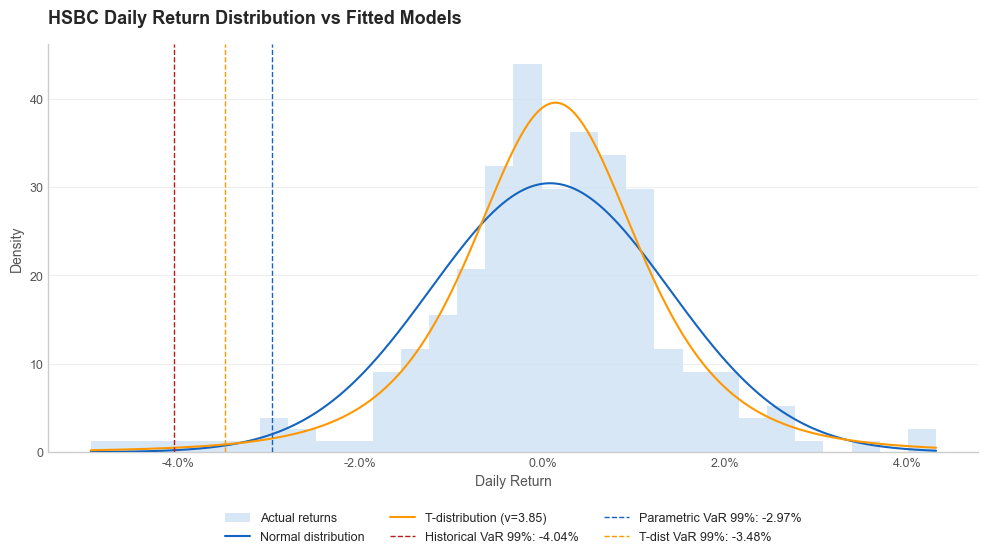

In [277]:
plot_return_distribution(returns, h_var, p_var, t_v)

In [278]:
def plot_pnl_drawdown(returns, portfolio_value=10000):
    cumulative = portfolio_value * (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")
    ax2.set_facecolor("white")

    ax1.plot(cumulative.index, cumulative, color="#1565C0", linewidth=1.2, label="Portfolio value", zorder=3)
    ax1.plot(cumulative.index, running_max, color="#888888", linewidth=0.8, linestyle="--", label="Peak value", zorder=2)
    ax1.fill_between(cumulative.index, cumulative, running_max, alpha=0.08, color="#1565C0", zorder=1)
    ax1.set_ylabel("Portfolio Value (£)", fontsize=10, color="#555555")
    ax1.set_title("HSBC Portfolio — Cumulative P&L and Drawdown", 
                 fontsize=13, fontweight="bold", pad=15, loc="left")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"£{y:,.0f}"))
    ax1.margins(y=0.05)

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["left"].set_color("#CCCCCC")
    ax1.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax1.xaxis.grid(False)
    ax1.tick_params(colors="#555555", labelsize=9)
    ax1.legend(loc="upper left", framealpha=0, fontsize=9, edgecolor="none")

    ax2.fill_between(drawdown.index, drawdown, 0, color="#B71C1C", alpha=0.2, zorder=1)
    ax2.plot(drawdown.index, drawdown, color="#B71C1C", linewidth=1, label="Drawdown", zorder=2)
    ax2.axhline(drawdown.min(), color="#B71C1C", linestyle=":", linewidth=0.8, 
               label=f"Max drawdown: {drawdown.min():.2%}", zorder=3)
    ax2.set_ylabel("Drawdown (%)", fontsize=10, color="#555555")
    ax2.set_xlabel("Date", fontsize=10, color="#555555")
    ax2.set_ylim(drawdown.min() * 1.3, 0.01)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#CCCCCC")
    ax2.spines["bottom"].set_color("#CCCCCC")
    ax2.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax2.xaxis.grid(False)
    ax2.tick_params(colors="#555555", labelsize=9)
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), 
              ncol=2, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(hspace=0.15, bottom=0.15)
    plt.show()

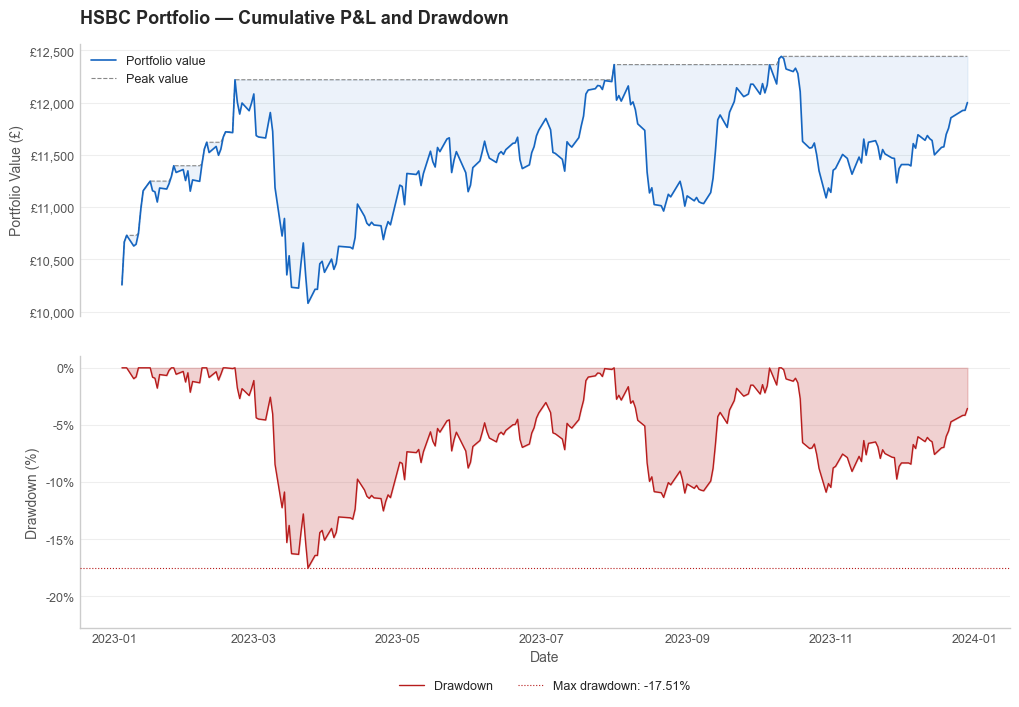

In [279]:
plot_pnl_drawdown(returns, portfolio_value)

In [ ]:
def plot_monte_carlo(max_drawdowns, actual_drawdown):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(max_drawdowns, bins=50, color="#CFE2F3", edgecolor="#1565C0", 
            linewidth=0.3, density=True, label="Simulated max drawdowns", zorder=2)

    ax.axvline(np.percentile(max_drawdowns, 50), color="#1565C0", linewidth=1, 
               linestyle="--", label=f"Median: {np.percentile(max_drawdowns, 50):.2%}", zorder=4)
    ax.axvline(np.percentile(max_drawdowns, 5), color="#FF9800", linewidth=1, 
               linestyle="--", label=f"95th percentile: {np.percentile(max_drawdowns, 5):.2%}", zorder=4)
    ax.axvline(actual_drawdown, color="#B71C1C", linewidth=1.5, 
               linestyle="-", label=f"Actual max drawdown: {actual_drawdown:.2%}", zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.set_title("Monte Carlo Simulation — Max Drawdown Distribution", 
                fontsize=13, fontweight="bold", pad=15, loc="left")
    ax.set_xlabel("Max Drawdown", fontsize=10, color="#555555")
    ax.set_ylabel("Density", fontsize=10, color="#555555")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.tick_params(colors="#555555", labelsize=9)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
             ncol=3, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(bottom=0.2)
    plt.show()

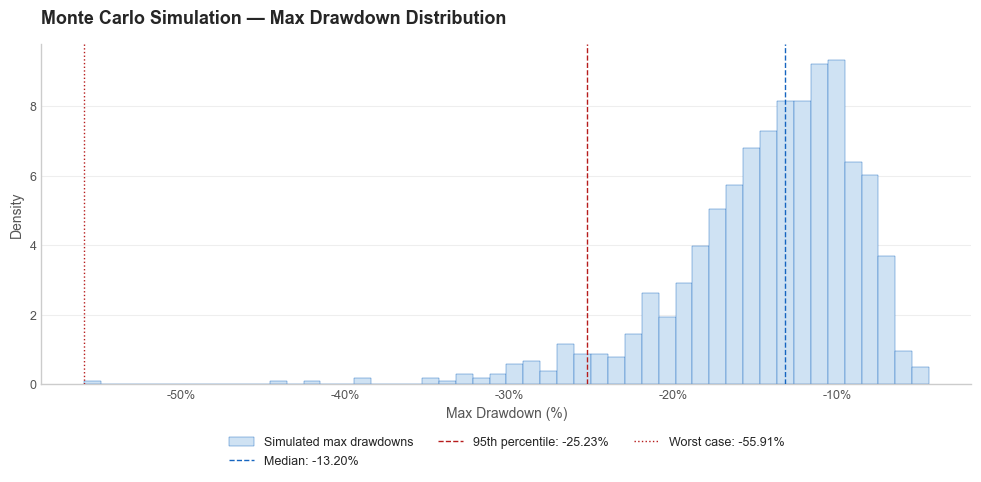

In [ ]:
actual_max_drawdown = drawdown.min()
plot_monte_carlo(max_drawdowns, actual_max_drawdown)